# 01 · gnomAD population frequency — a variant classifier in its own right

**CFTR Variant Toolkit · Notebook 1 of the series**

Before you trust *any* computational prediction that a variant is "pathogenic," there is one
cheap, powerful check: **how common is this variant in the general population?**

That number comes from **gnomAD** (the *Genome Aggregation Database*,
[gnomad.broadinstitute.org](https://gnomad.broadinstitute.org)). This notebook uses **gnomAD
v4.1.1** — the Broad Institute's 2026-03-30 patch of the v4.1 exome+genome joint-calling
release (2024-04-19), which aggregates ~730,000 exomes + ~76,000 genomes (~807,000 people
total), none selected for cystic fibrosis (CF) or any single disease. It is our best available
snapshot of "normal" human genetic variation.

### Why a bench scientist should care

AlphaMissense, EVE, REVEL, ESM1b, and PrimateAI (tools/02–06) all solve the same narrow
problem: score a single amino-acid substitution against protein sequence and structure.
gnomAD is a different kind of evidence — not a sequence model at all, but a direct census of
which variants actually exist in living humans, and how often. It classifies CFTR **gene-wide**,
not just missense: every variant gnomAD has observed gets a population frequency, whether it
changes an amino acid, sits in an intron, or truncates the protein outright. That makes it both
a classification method in its own right, and (because it's independent of any sequence model)
a check on what the missense predictors say.

The key idea of this notebook, in one sentence:

> **A truly CF-causing recessive allele is almost always rare. So a variant sitting at a
> *common* population frequency needs a very good reason to also be called pathogenic.**

Every table in this toolkit carries a `source` column; every table in this notebook is
`source == 'REAL'` (genuine gnomAD v4.1.1 data, not illustrative demo numbers).


In [1]:
import sys, pathlib
# `toolkit` is THIS repo's toolkit.py (one directory up) — NOT a pip
# package and nothing to do with gnomAD. The line below puts the repo
# root on sys.path so `import toolkit` resolves to ../toolkit.py.
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import toolkit as tk
import pandas as pd, numpy as np
# %matplotlib inline is a Jupyter magic: it draws matplotlib plots inline below the cell
%matplotlib inline


## What is allele frequency (AF)?

Every position in your genome comes in **two copies** (one from each parent). Each copy is an
**allele**. Across a population of *N* people there are *2N* alleles at any given site.

$$\text{AF} = \frac{\text{number of chromosomes carrying the variant}}{\text{total number of chromosomes tested}}$$

So an AF of `0.001` means 1 in 1,000 chromosomes carries the variant; an AF of `0.5` means half
of all chromosomes carry it (that is a *coin-flip-common* variant — clearly not a rare disease
allele on its own, though see the F508del discussion below for why "common" and "recessive
disease allele" are not mutually exclusive).

**Exome AF vs genome AF.** gnomAD sequences two cohorts separately:

- **Exome AF** — from *exome sequencing*, which reads only the ~2% of the genome that codes for
  protein. Cheaper, so gnomAD has far more exome samples — good statistical power for coding
  (e.g. missense) variants.
- **Genome AF** — from *whole-genome sequencing*, which reads everything including deep
  introns. Fewer samples, but the **only** way to see variants that fall outside the exome (the
  deep-intronic splice variants we meet later).

gnomAD v4.1 also publishes a **joint** frequency across both cohorts — allele counts summed
together before dividing, not just whichever cohort's own AF happens to be larger. This toolkit
exposes that joint figure as `gnomad_af` (mechanics and citation in the next section).

*(AF definition & the gnomAD reference dataset: Karczewski et al. 2020, *Nature*, PMID 32461654.)*

### The ACMG connection: BS1 and BA1

Clinical geneticists formalized the "too common to cause disease" logic in the **ACMG/AMP** —
**A**merican **C**ollege of **M**edical **G**enetics and Genomics and the **A**ssociation for
**M**olecular **P**athology — variant-classification guidelines (Richards et al. 2015, *Genet
Med*, PMID 25741868). Two of their *benign* evidence codes are pure frequency arguments:

| Code | Meaning | Rough idea |
|------|---------|-----------|
| **BA1** | *stand-alone benign* | AF is so high the variant **cannot** cause a rare recessive disease (e.g. AF > 5%). |
| **BS1** | *strong benign* | AF is *greater than expected* for the disease — too common to be a typical CF allele. |

CF is a **recessive** disease: you need a damaging variant on **both** copies of *CFTR* to be
affected. Damaging alleles are kept rare by natural selection, so most bona-fide CF-causing
variants sit at **AF < 1e-3** (below 0.1%), and many well below 1e-4. That is the threshold
intuition we will now check against real data — with two instructive exceptions, R117H and
F508del, discussed below: biology always has caveats.


## Fetching the REAL data — gnomAD's public GraphQL API

There is no precomputed per-gene gnomAD download to point at: the browser itself is powered by
a public **GraphQL API** at `https://gnomad.broadinstitute.org/api`, so that is what this cell
queries directly — the same request the gnomAD website makes when you search "CFTR." No login,
key, or bulk download needed.

**One request returns every CFTR variant** (~7,577, all consequence classes at once); we
classify each one locally into `missense` / `noncoding` / `other_coding` by its `consequence`
field — the next section defines exactly what each bucket means. **No quality filter is
applied** — that's deliberate; the funnel further down shows what gets hidden and why.

**How `gnomad_af` is actually computed.** gnomAD v4.1 sequences exomes and genomes as two
separate, mostly non-overlapping cohorts (~730,000 people vs. ~76,000 people) and, since v4.1,
also reports a **joint** allele count/number: the two cohorts' allele counts summed together
before dividing (`joint.ac / joint.an`). This notebook uses that joint figure as `gnomad_af` —
a real combined-cohort estimate, computed by merging the underlying counts, not by comparing two
independently-normalized proportions and keeping whichever is larger. (The formal
ACMG-endorsed metric for BS1/BA1 is gnomAD's **Grpmax Filtering AF** — the lower 95%-confidence
bound of the single highest ancestry-group frequency, deliberately excluding
Amish/Ashkenazi-Jewish/Finnish/Middle-Eastern founder populations; ClinGen SVI guidance, March
2024. `gnomad_af` here is a simpler stand-in: correct for the "is this common" teaching question
this notebook asks, but a real ACMG curation should pull Grpmax FAF from the gnomAD browser, not
this column.)

**How far does "the CFTR gene" reach?** gnomAD's per-gene query isn't scoped to one clinical
transcript. Ensembl's CFTR gene model (`ENSG00000001626`) merges all 45 annotated transcript
isoforms into one genomic span, chr7:117,287,120–117,715,971 (GRCh38, ~429 kb) — much wider
than the canonical MANE transcript alone, NM_000492.4 / ENST00000003084,
chr7:117,480,025–117,668,665 (~189 kb, 27 exons). The variants gnomAD actually returns span
chr7:117,480,021–117,715,931 (printed live below): flush with the canonical transcript's 5′
end, but reaching ~47 kb past its 3′ end into exons that belong only to a minor isoform. Don't
assume "CFTR variant from this API" means "inside the ~189 kb canonical gene."

The cell below writes `gnomad_cftr_all.tsv` to `data/` (skipping the request if it already
exists). Delete it to re-fetch. gnomAD publishes under **ODbL + MIT terms** (see
`data_manifest.json`).


In [2]:
import requests

DATA_DIR = pathlib.Path.cwd().parent / "data"
ALL_TSV = DATA_DIR / "gnomad_cftr_all.tsv"

GNOMAD_API = "https://gnomad.broadinstitute.org/api"
GNOMAD_QUERY = """
query CFTRVariants($geneId: String!, $referenceGenome: ReferenceGenomeId!, $datasetId: DatasetId!) {
  gene(gene_id: $geneId, reference_genome: $referenceGenome) {
    start
    stop
    variants(dataset: $datasetId) {
      variant_id
      hgvsc
      hgvsp
      consequence
      exome { ac an af filters }
      genome { ac an af filters }
      joint { ac an filters }
    }
  }
}
"""

# missense: the single-residue substitutions AlphaMissense/EVE/REVEL/ESM1b/PrimateAI score.
# noncoding: outside what those predictors model at all.
# other_coding: protein-coding but not a substitution -- also unscoreable by a missense
# predictor, but for a different reason (see the classification table below).
NONCODING_CONSEQUENCES = {
    "intron_variant", "synonymous_variant", "splice_region_variant",
    "3_prime_UTR_variant", "5_prime_UTR_variant",
    "splice_acceptor_variant", "splice_donor_variant",
}
OTHER_CODING_CONSEQUENCES = {
    "stop_gained", "frameshift_variant", "inframe_deletion", "inframe_insertion",
    "start_lost", "stop_lost", "stop_retained_variant",
}


def classify(consequence: str) -> str:
    if consequence == "missense_variant":
        return "missense"
    if consequence in NONCODING_CONSEQUENCES:
        return "noncoding"
    if consequence in OTHER_CODING_CONSEQUENCES:
        return "other_coding"
    return "other"  # any consequence class gnomAD adds later that we haven't bucketed


def fetch_gnomad_cftr() -> pd.DataFrame:
    """Query gnomAD v4.1.1 (GraphQL) for every CFTR variant. REAL, live, no local file needed."""
    resp = requests.post(GNOMAD_API, json={
        "query": GNOMAD_QUERY,
        "variables": {"geneId": "ENSG00000001626",       # CFTR Ensembl gene ID
                      "referenceGenome": "GRCh38", "datasetId": "gnomad_r4"},
    }, timeout=60)
    resp.raise_for_status()
    payload = resp.json()
    if "errors" in payload:
        raise RuntimeError(f"gnomAD GraphQL error: {payload['errors']}")
    gene = payload["data"]["gene"]
    print(f"gnomAD gene region queried (union of all CFTR transcript isoforms): "
          f"chr7:{gene['start']:,}-{gene['stop']:,} (GRCh38)")

    df = pd.DataFrame(gene["variants"])
    for cohort in ("exome", "genome", "joint"):
        sub = df.pop(cohort)
        df[f"{cohort}_ac"] = sub.apply(lambda d: d["ac"] if d else None)
        df[f"{cohort}_an"] = sub.apply(lambda d: d["an"] if d else None)
        if cohort != "joint":
            df[f"{cohort}_af"] = sub.apply(lambda d: d["af"] if d else None)
        df[f"{cohort}_filters"] = sub.apply(
            lambda d: ",".join(d["filters"]) if d and d.get("filters") else ("PASS" if d else ""))

    df["gnomad_af"] = df["joint_ac"] / df["joint_an"]
    df["gnomad_class"] = df["consequence"].apply(classify)
    df = df.rename(columns={"hgvsc": "hgvs_c", "hgvsp": "hgvs_p"})

    pos = df["variant_id"].str.split("-").str[1].astype(int)
    print(f"gnomAD returned {len(df):,} CFTR variants, positions "
          f"chr7:{pos.min():,}-{pos.max():,} (GRCh38)")
    return df


if ALL_TSV.exists():
    print(f"already fetched -> {ALL_TSV.name} (delete to re-fetch)")
else:
    DATA_DIR.mkdir(exist_ok=True)
    all_variants = fetch_gnomad_cftr()
    cols = ["variant_id", "hgvs_c", "hgvs_p", "consequence", "gnomad_class",
            "exome_ac", "exome_an", "exome_af", "exome_filters",
            "genome_ac", "genome_an", "genome_af", "genome_filters",
            "joint_ac", "joint_an", "joint_filters", "gnomad_af"]
    all_variants[cols].to_csv(ALL_TSV, sep="\t", index=False)
    print(f"wrote {len(all_variants):,} rows -> {ALL_TSV.relative_to(DATA_DIR.parent)}")
    print()
    print(all_variants["gnomad_class"].value_counts().rename("n_variants").to_string())


already fetched -> gnomad_cftr_all.tsv (delete to re-fetch)


## Load the real gnomAD table — all of CFTR, classified

`tk.load_gnomad_all()` reads the extract the cell above just fetched (or skipped, if it already
existed): every CFTR variant gnomAD v4.1.1 reports, each tagged with a `gnomad_class`:

| `gnomad_class` | consequence classes | can a missense predictor score it? |
|---|---|---|
| **missense** | `missense_variant` | **Yes** — this is the exact substrate AlphaMissense/EVE/REVEL/ESM1b/PrimateAI were built for: one amino acid swapped for another. |
| **noncoding** | intron, synonymous, 5′/3′ UTR, splice-region/acceptor/donor | **No** — outside the region those models look at, full stop. This is the substrate for the SpliceAI/Pangolin notebooks later. |
| **other_coding** | stop_gained, frameshift, inframe indel, start/stop lost/retained | **No, for a different reason** — these change the protein sequence but aren't a single-residue substitution, which is the only kind of change a missense predictor's model computes. Clinically these usually go through ACMG's **PVS1** (predicted loss-of-function) rule instead of a missense-style score. |

The columns:

| column | meaning |
|--------|---------|
| `variant_id` | genomic key `chrom-pos-ref-alt` (GRCh38) |
| `hgvs_c` | change at the DNA/coding level, e.g. `c.5A>C` |
| `hgvs_p` | change at the protein level, e.g. `p.Gln2Pro` |
| `protein_variant` | short form of the protein change, e.g. `Q2P` (the join key other missense-tool notebooks use) |
| `consequence` | gnomAD's own variant-effect class, e.g. `missense_variant` |
| `gnomad_class` | this notebook's 3-way bucket, derived from `consequence` (table above) |
| `exome_af` / `genome_af` | per-cohort allele frequency |
| `exome_filters` / `genome_filters` / `joint_filters` | QC filter tags (`"PASS"`, or comma-separated failed-filter names); see the funnel below |
| `gnomad_af` | **joint population allele frequency** — the star of this notebook |
| `source` | `REAL` — genuine gnomAD data |

`load_gnomad_all()` itself is a thin reader in `toolkit.py`. `load_gnomad_missense()` and
`load_gnomad_noncoding()` — used by the missense-predictor notebooks and the splice-variant
analysis — are thin filters over this same table (`gnomad_class == "missense"` /
`"noncoding"`), so all three views stay consistent by construction: there is only one fetch, one
table, and one classification rule.


### Aside: the five ways a CFTR variant gets named — and why joins silently fail

You have just met four different identifiers for the same variant (`variant_id`, `hgvs_c`,
`hgvs_p`, `protein_variant`). That is not an accident of this table: CFTR variants genuinely
travel under several naming systems, and **most apparent "disagreements between tools" turn
out to be key mismatches, not biology.** Worth knowing before you join anything.

| Key type | Example | Where you meet it | What goes wrong |
|---|---|---|---|
| Protein, 1-letter | `G551D` | AlphaMissense, EVE, ESM1b, and this notebook's `protein_variant` | only exists for missense — it is empty for every intronic, synonymous or truncating variant |
| Protein, 3-letter | `Gly551Asp` | ClinVar `Name`, some curated tables | must be converted before it will join; `three_to_one()` in `toolkit.py` does it |
| HGVS coding | `c.1652G>A` | CFTR2, clinical reports | only meaningful against a stated transcript — this toolkit uses MANE Select `NM_000492.4` throughout |
| Legacy CFTR name | `2789+5G>A` | older literature, CFTR2 history | no formula converts it; it can only be looked up |
| Genomic coordinate | `7-117587799-G-A` (`chrom,pos,ref,alt`) | REVEL and the other coordinate-keyed tools, and `variant_id` above | wrong genome build joins to nothing, silently |

Two specifics worth committing to memory:

**CFTR is on the plus strand.** So the genomic `ref`/`alt` reads the *same* as the coding
change — coding `c.1624G>T` appears as `G`→`T`, not `C`→`A`. Do **not** reverse-complement.
The real hazard is not strand, it is joining across genome builds (GRCh37 vs GRCh38) or across
key types.

**A failed join looks like an empty result, not an error.** `pandas.merge` on a mismatched key
returns zero rows perfectly happily. When a tool "has no score" for a variant you are sure it
covers, check the key before concluding anything about coverage — `hgvsp_to_short()` and
`three_to_one()` in `toolkit.py` are the helpers that normalise between these forms.


In [3]:
all_cftr = tk.load_gnomad_all()
assert (all_cftr["source"] == "REAL").all(), "unexpected non-REAL rows!"

print(f"rows: {len(all_cftr):,}   columns: {list(all_cftr.columns)}")
print()
print(all_cftr["gnomad_class"].value_counts().rename("n_variants").to_string())
print()
print("consequence breakdown within each class:")
print(all_cftr.groupby("gnomad_class")["consequence"].value_counts().to_string())


rows: 7,577   columns: ['variant_id', 'hgvs_c', 'hgvs_p', 'consequence', 'gnomad_class', 'exome_ac', 'exome_an', 'exome_af', 'exome_filters', 'genome_ac', 'genome_an', 'genome_af', 'genome_filters', 'joint_ac', 'joint_an', 'joint_filters', 'gnomad_af', 'protein_variant', 'source']

gnomad_class
noncoding       4717
missense        2466
other_coding     394

consequence breakdown within each class:
gnomad_class  consequence            
missense      missense_variant           2466
noncoding     intron_variant             3325
              synonymous_variant          736
              splice_region_variant       239
              3_prime_UTR_variant         224
              5_prime_UTR_variant          83
              splice_acceptor_variant      56
              splice_donor_variant         54
other_coding  frameshift_variant          198
              stop_gained                 148
              inframe_deletion             32
              start_lost                    6
         

In [4]:
missense = tk.load_gnomad_missense()

print(f"rows: {len(missense):,}   columns: {list(missense.columns)}")
print(f"source values present: {missense['source'].unique().tolist()}")
missense.head()

,variant_id,hgvs_c,hgvs_p,consequence,gnomad_class,exome_ac,exome_an,exome_af,exome_filters,genome_ac,genome_an,genome_af,genome_filters,joint_ac,joint_an,joint_filters,gnomad_af,protein_variant,source
0,7-117480021-C-A,c.-74C>A,NaN,5_prime_UTR_variant,noncoding,0.0,1219880.0,0.000000e+00,AC0,NaN,NaN,NaN,NaN,0,1371998,AC0,0.000000e+00,None,REAL
1,7-117480021-CAG-C,c.-71_-70del,NaN,5_prime_UTR_variant,noncoding,1.0,1219886.0,8.197487e-07,PASS,NaN,NaN,NaN,NaN,1,1372004,PASS,7.288608e-07,None,REAL
2,7-117480023-G-T,c.-72G>T,NaN,5_prime_UTR_variant,noncoding,0.0,1233618.0,0.000000e+00,AC0,NaN,NaN,NaN,NaN,0,1385866,AC0,0.000000e+00,None,REAL
3,7-117480025-G-A,c.-70G>A,NaN,5_prime_UTR_variant,noncoding,5.0,1246304.0,4.011862e-06,PASS,NaN,NaN,NaN,NaN,5,1398542,PASS,3.575152e-06,None,REAL
4,7-117480026-T-C,c.-69T>C,NaN,5_prime_UTR_variant,noncoding,2.0,1244428.0,1.607164e-06,PASS,NaN,NaN,NaN,NaN,2,1395848,PASS,1.432821e-06,None,REAL


In [4]:
# Sanity check that we are looking at 100% REAL data (no demo rows mixed in).
assert (missense["source"] == "REAL").all(), "unexpected non-REAL rows!"
print(f"All {len(missense):,} CFTR missense variants are source == 'REAL' (genuine gnomAD v4).")

All 2,466 CFTR missense variants are source == 'REAL' (genuine gnomAD v4).


## Where do these counts come from? The gnomAD QC funnel

`load_gnomad_all()` returns every variant the GraphQL API reports — **no quality filter
applied** — so you can see exactly what a database's default view hides and why. gnomAD's own
browser applies its default filter (PASS + AC>0) before showing you a count, which is why this
toolkit's raw counts differ from what you'd see searching "CFTR" on gnomad.broadinstitute.org.

Two QC filters do the hiding:

- **AC0** — genotype-level. After removing low-confidence individual genotypes (depth < 10x,
  genotype quality < 20, or allele balance ≤ 0.2 for a heterozygous call), the variant's allele
  count drops to zero: nobody left in the cohort has a genotype good enough to count as a real
  carrier.
- **AS_VQSR** — site-level. GATK's Allele-Specific Variant Quality Score Recalibration scores
  each site's read-level statistics (depth, strand bias, mapping quality, …) against
  known-good/known-bad training variants and flags likely sequencing artifacts. It's computed
  separately per sequencing type (exome vs genome are called independently) — `exome_filters`
  and `genome_filters` above can carry it; `joint_filters` (used for the funnel below) rolls
  both cohorts into a single PASS/AC0 call.

The funnel below is computed live from `joint_filters` on every fetched variant, for **all
three** classes — not a hardcoded estimate:


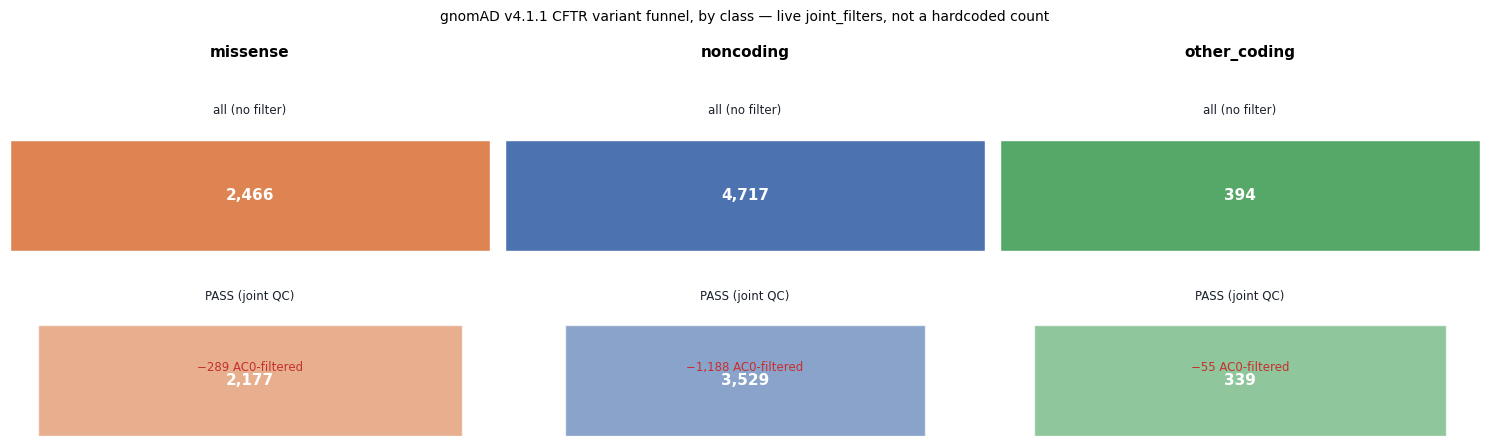

missense      : 2,466 total -> 2,177 PASS ( 88.3%),   289 AC0-filtered (11.7%)
noncoding     : 4,717 total -> 3,529 PASS ( 74.8%), 1,188 AC0-filtered (25.2%)
other_coding  :   394 total ->   339 PASS ( 86.0%),    55 AC0-filtered (14.0%)


In [5]:
import matplotlib.pyplot as plt

CLASS_COLORS = {"missense": "#dd8452", "noncoding": "#4c72b0", "other_coding": "#55a868"}

funnel_rows = []
for cls in ("missense", "noncoding", "other_coding"):
    sub = all_cftr[all_cftr["gnomad_class"] == cls]
    total = len(sub)
    passed = int((sub["joint_filters"] == "PASS").sum())
    ac0 = total - passed
    funnel_rows.append((cls, total, passed, ac0))

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (cls, total, passed, ac0) in zip(axes, funnel_rows):
    stages = [("all (no filter)", total), ("PASS (joint QC)", passed)]
    for i, (label, n) in enumerate(stages):
        y = 1 - i
        w = n / total
        ax.barh(y, w, left=(1 - w) / 2, height=0.6, color=CLASS_COLORS[cls],
                 alpha=1.0 - 0.35 * i, edgecolor="white")
        ax.text(0.5, y, f"{n:,}", ha="center", va="center", color="white",
                 fontsize=11, fontweight="bold")
        ax.text(0.5, y + 0.42, label, ha="center", va="bottom", fontsize=8.5, color="#1a202c")
    ax.annotate(f"−{ac0:,} AC0-filtered", xy=(0.5, 0.05), ha="center",
                 fontsize=8.5, color="#c53030")
    ax.set_xlim(0, 1); ax.set_ylim(-0.3, 1.7); ax.axis("off")
    ax.set_title(cls, fontsize=11, fontweight="bold")

fig.suptitle("gnomAD v4.1.1 CFTR variant funnel, by class — live joint_filters, not a hardcoded count",
             fontsize=10)
fig.tight_layout()
plt.show()

for cls, total, passed, ac0 in funnel_rows:
    print(f"{cls:14}: {total:>5,} total -> {passed:>5,} PASS ({passed/total:6.1%}), "
          f"{ac0:>5,} AC0-filtered ({ac0/total:5.1%})")


## The shape of population variation across the whole gene

Allele frequencies span many orders of magnitude — from ~`1e-6` (seen on a handful of
chromosomes out of ~1.6 million) up to ~`0.5`. Plotting raw AF would cram everything against
zero, so we plot **log10(AF)**, which spreads the values out and makes the structure visible —
now across all three `gnomad_class` buckets at once, colored separately, so you can see whether
"most variants are rare" holds gene-wide or only for missense.

A couple of housekeeping points before the plot:

- We keep only variants with **AF > 0**. A `0` (or missing) AF means the variant was *never
  observed* in gnomAD — `log10(0)` is undefined, so those can't go on a log axis. (They are
  effectively "ultra-rare / private" and would pile up at the far-left edge anyway.)
- On the x-axis, **−6 means AF = 1e-6** (ultra-rare) and **−1 means AF = 0.1** (common).
  **Further left = rarer.**


6,078 variants with AF > 0 are plotted; 1,499 had AF == 0 / missing (never seen in gnomAD, or joint AN == 0) and are omitted.


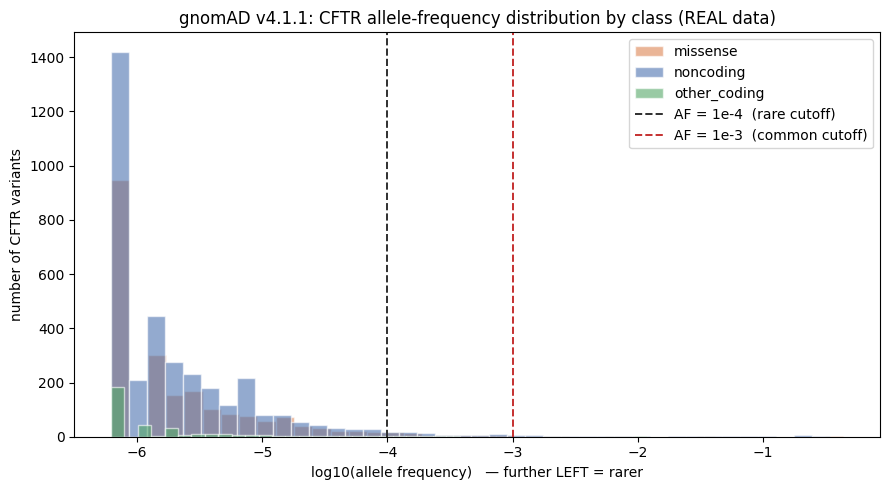

In [6]:
import matplotlib.pyplot as plt

# Keep observed variants only (AF > 0) so log10 is defined.
observed = all_cftr[all_cftr["gnomad_af"] > 0].copy()
observed["log10_af"] = np.log10(observed["gnomad_af"])

n_zero = len(all_cftr) - len(observed)
print(f"{len(observed):,} variants with AF > 0 are plotted; "
      f"{n_zero:,} had AF == 0 / missing (never seen in gnomAD, or joint AN == 0) and are omitted.")

fig, ax = plt.subplots(figsize=(9, 5))
for cls, color in CLASS_COLORS.items():
    sub = observed[observed["gnomad_class"] == cls]
    ax.hist(sub["log10_af"], bins=40, color=color, alpha=0.6, edgecolor="white", label=cls)

# Guide lines for the 'rare' (1e-4) and 'common' (1e-3) cut-points we use next.
ax.axvline(np.log10(1e-4), color="#2f2f2f", linestyle="--", linewidth=1.4,
           label="AF = 1e-4  (rare cutoff)")
ax.axvline(np.log10(1e-3), color="#c53030", linestyle="--", linewidth=1.4,
           label="AF = 1e-3  (common cutoff)")

ax.set_xlabel("log10(allele frequency)   — further LEFT = rarer")
ax.set_ylabel("number of CFTR variants")
ax.set_title("gnomAD v4.1.1: CFTR allele-frequency distribution by class (REAL data)")
ax.legend()
plt.tight_layout()
plt.show()


**Read the histogram left-to-right.** The mass of every class sits on the **left** — the
overwhelming majority of *CFTR* variants, missense or not, are rare or ultra-rare (AF well below
`1e-4`). Only a thin tail of any class reaches to the **right** of the red line into "common"
territory.

This is exactly what population genetics predicts: functionally important genes like *CFTR*
tolerate very few common protein-affecting or splice-critical variants, because most such
changes are either harmless-but-rare or removed by selection. **The rarity of a variant is the
default expectation — commonness is the exception worth investigating**, whichever class it
falls in.


## Counting: rare vs common, and who the common ones are

Let's put numbers on the picture, across all three classes, using the thresholds from the
histogram:

- **rare**: `AF < 1e-4` (below 0.01%) — the frequency band where genuine CF-causing alleles
  live.
- **common**: `AF > 1e-3` (above 0.1%) — too common for a *typical* recessive CF allele; these
  light up **BS1/BA1** benign evidence — usually correctly, but not always (see below).

(The band between `1e-4` and `1e-3` is a grey zone we leave unlabelled here.)


In [7]:
summary = all_cftr.groupby("gnomad_class").apply(lambda g: pd.Series({
    "n": len(g),
    "rare (AF<1e-4)": int((g["gnomad_af"] < 1e-4).sum()),
    "common (AF>1e-3)": int((g["gnomad_af"] > 1e-3).sum()),
}), include_groups=False)
summary["rare_pct"] = (summary["rare (AF<1e-4)"] / summary["n"]).map("{:.1%}".format)
summary["common_pct"] = (summary["common (AF>1e-3)"] / summary["n"]).map("{:.1%}".format)
summary


,n,rare (AF<1e-4),common (AF>1e-3),rare_pct,common_pct
gnomad_class,,,,,
missense,2466,2386,15,96.8%,0.6%
noncoding,4717,4604,40,97.6%,0.8%
other_coding,394,388,1,98.5%,0.3%


In [8]:
# Every 'common' variant across all three classes, most-common first. These are the BS1/BA1 flags.
common = all_cftr[all_cftr["gnomad_af"] > 1e-3].copy()
common["protein_variant"] = common["hgvs_p"].apply(tk.hgvsp_to_short)
common_sorted = common.sort_values("gnomad_af", ascending=False)
common_sorted[["gnomad_class", "protein_variant", "hgvs_c", "hgvs_p", "consequence",
               "gnomad_af", "source"]].reset_index(drop=True)


,gnomad_class,protein_variant,hgvs_c,hgvs_p,consequence,gnomad_af,source
0,missense,V470M,c.1408G>A,p.Val470Met,missense_variant,0.439120,REAL
1,noncoding,T854T,c.2562T>G,p.Thr854Thr,synonymous_variant,0.344931,REAL
2,noncoding,None,c.1393-61A>G,NaN,intron_variant,0.232569,REAL
3,noncoding,Q1463Q,c.4389G>A,p.Gln1463Gln,synonymous_variant,0.225177,REAL
4,noncoding,None,c.744-9_744-6del,NaN,intron_variant,0.213731,REAL
5,noncoding,None,c.1210-13_1210-12del,NaN,intron_variant,0.210215,REAL
6,noncoding,None,c.3469-65C>A,NaN,intron_variant,0.191206,REAL
7,noncoding,None,c.1210-13_1210-12dup,NaN,intron_variant,0.121520,REAL
8,noncoding,None,c.1210-13G>T,NaN,intron_variant,0.079448,REAL
9,noncoding,None,c.869+11C>T,NaN,intron_variant,0.076511,REAL


### Interpreting the common list

Notice `source` is still `REAL` for every row — these frequencies are real.

- **The top entry, `V470M` (AF ≈ 0.56), is the classic teaching example.** It is
  the common **M470V polymorphism** of *CFTR* (you'll see it written either way
  depending on which allele the database treats as reference; here the
  alternate allele is the *M→V* direction, hence `V470M`). It occurs on **more
  than half** of all human chromosomes. A variant that common **cannot** be a
  penetrant CF-causing allele — it is a benign polymorphism, a **BA1** call. If a
  missense predictor ever flags it as "pathogenic," that is a failure of the
  predictor, not a discovery about the patient.

- Most other rows (`R668C`, `R75Q`, `S1235R`, …) are likewise **benign or
  low-impact** — far too common to be classic CF alleles.

- **The instructive exception is `R117H` (AF ≈ 2e-3).** It is genuinely
  *CF-causing but mild/variable*, and it is relatively common **because** its
  effect is mild (weak selection lets it persist). This is the caveat to keep
  you honest: "common ⇒ benign" is a strong **prior**, not an absolute law. The
  frequency filter flags candidates for scrutiny; it does not overrule
  functional and clinical evidence on its own. This nuance is exactly why ACMG
  distinguishes stand-alone **BA1** from merely-strong **BS1**.

## Beyond missense: the variants your protein predictor can't see

A missense predictor only scores changes to the **amino-acid sequence**. But a
lot of *CFTR* pathology hides in variants that leave the protein sequence
untouched — deep in introns, in synonymous ("silent") codons, or right at the
edges of exons where the **splicing** machinery reads the RNA.

`tk.load_gnomad_noncoding()` loads the *CFTR* variants from the **same real
gnomAD v4** source, but from these non-missense consequence classes. Because
many of them live outside the exome, this table also exposes separate
`exome_af` and `genome_af` columns.

In [9]:
noncoding = tk.load_gnomad_noncoding()

print(f"rows: {len(noncoding):,}   source: {noncoding['source'].unique().tolist()}")
print(f"columns: {list(noncoding.columns)}")

# Consequence breakdown — what KINDS of non-coding variation are here.
noncoding["consequence"].value_counts()

rows: 4,717   source: ['REAL']
columns: ['variant_id', 'hgvs_c', 'hgvs_p', 'consequence', 'exome_af', 'genome_af', 'gnomad_af', 'source']


consequence
intron_variant             3325
synonymous_variant          736
splice_region_variant       239
3_prime_UTR_variant         224
5_prime_UTR_variant          83
splice_acceptor_variant      56
splice_donor_variant         54
Name: count, dtype: int64

### Why this breakdown motivates a whole separate analysis

Read the counts above:

- **`intron_variant`** dominates. Most are harmless, but a small number are
  **deep-intronic splice variants** that create a *cryptic* splice site and
  wreck the transcript — classic CF alleles like `c.3849+10kbC>T` live here.
  They are **completely invisible** to any missense predictor, because they
  never change an amino acid.
- **`synonymous_variant`** ("silent") changes look harmless — same protein — yet
  a few disrupt splicing regulatory elements near exon boundaries.
- **`splice_acceptor_variant` / `splice_donor_variant` / `splice_region_variant`**
  sit right at the exon–intron junctions the spliceosome depends on.

None of these are scoreable by AlphaMissense, EVE, REVEL, or ESM1b. They need a
different class of tool — **splice predictors** such as SpliceAI and Pangolin —
which is the subject of a later notebook. The point for *this* notebook: gnomAD
frequency is the one filter that applies **uniformly** across *all* of these
classes, coding and non-coding alike.

## Key takeaways

1. **gnomAD v4.1.1 (~807k people) is a classification method in its own right.** Every CFTR
   variant it has observed — missense, noncoding, or protein-truncating — gets a population
   frequency. That's independent of any sequence-based model, which is also what lets it serve
   as a check on the missense predictors in tools/02–06.

2. **Rare is the default; common is the exception worth investigating** — gene-wide, not just
   for missense. All three `gnomad_class` buckets show the same overwhelmingly-rare shape
   (AF < 1e-4 for the large majority). A "pathogenic" call sitting on a common variant should
   make you suspicious of the call — ACMG's **BS1** (strong benign) / **BA1** (stand-alone
   benign) logic.

3. **Two concrete "common" examples point in opposite directions.** V470M (missense, AF ≈ 0.44)
   is a benign polymorphism, full stop — any tool calling it pathogenic is wrong. **F508del**
   (other_coding, AF ≈ 1.2%) is the single most common CF-causing variant on Earth, common
   *because* CF is recessive and F508del is a population founder allele — its AF tracks carrier
   frequency (Hardy–Weinberg), not disease risk.

4. **"Common ⇒ benign" is therefore a strong prior, not a law.** F508del and R117H both sit
   above the naive 1e-3 threshold while remaining pathogenic (or mild-but-pathogenic), for
   related but distinct reasons. Use frequency to *triage and flag*; let functional and clinical
   evidence adjudicate the edge cases. For real ACMG curation, use gnomAD's Grpmax Filtering AF,
   not the simpler joint `gnomad_af` this notebook uses for teaching clarity.

5. **Missense predictors only reach one of gnomAD's three classes.** `noncoding` variants are
   invisible to them because they sit outside the region those models look at, full stop;
   `other_coding` variants are invisible because they aren't single-residue substitutions — a
   different problem, usually handled via ACMG's PVS1 rule instead of a missense-style score.
   gnomAD frequency is the one filter that applies uniformly across all three — motivating the
   splice-predictor notebooks, [`../tools/07_spliceai.ipynb`](../tools/07_spliceai.ipynb) and
   [`../tools/08_pangolin.ipynb`](../tools/08_pangolin.ipynb), which score exactly the
   `noncoding` class this one cannot.

**Next up:** feed these same variants into the missense predictors and watch how often their
calls line up with — or diverge from — this frequency evidence.
